In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from perturbgen.configs import ROOT
import datetime
import random
from matplotlib import style

In [2]:
os.chdir(ROOT)
print(f'Current working directory: {os.getcwd()}')

Current working directory: /lustre/scratch126/cellgen/lotfollahi/kl11


In [3]:
date = datetime.datetime.now().strftime("%Y%m%d")

In [4]:
np.random.seed(42)
random.seed(42)

In [5]:
os.chdir(ROOT)
print(f'Current working directory: {os.getcwd()}')

Current working directory: /lustre/scratch126/cellgen/lotfollahi/kl11


In [6]:
res_dir = 'T_perturb/res/hspc/tf_perturbation/'
# create directory if it does not exist
if not os.path.exists(res_dir):
    os.makedirs(res_dir)

In [ ]:
style.use('default')
style.use(
    '/lustre/scratch126/cellgen/lotfollahi/kl11/'
    'T_perturb/perturbgen/pp/mpl_style.mplstyle'
)


### 1. Compare perturbation methods

In [8]:
# load dataframes
delete_csv = pd.read_csv('/lustre/scratch126/cellgen/lotfollahi/kl11/T_perturb/res/hspc/tf_perturbation/20260226_intermediate_delete_ep14_memp_prog_new_metrics_direction_per_gene.csv', header=0)
pad_csv = pd.read_csv('/lustre/scratch126/cellgen/lotfollahi/kl11/T_perturb/res/hspc/tf_perturbation/20260226_intermediate_pad_ep14_memp_prog_new_metrics_direction_per_gene.csv', header=0)
mask_csv = pd.read_csv('/lustre/scratch126/cellgen/lotfollahi/kl11/T_perturb/res/hspc/tf_perturbation/20260226_intermediate_mask_ep14_memp_prog_new_metrics_direction_per_gene.csv', header=0)
# stem_csv = pd.read_csv('T_perturb/res/hspc/tf_perturbation/20251008_stem_pred_ep14_erythro_mk_metrics.csv', header=0)

delete_csv['method'] = 'delete'
pad_csv['method'] = 'pad'
mask_csv['method'] = 'mask'
# stem_csv['method'] = 'stem'

In [9]:
# concatenate dataframes
combined_df = pd.concat([delete_csv, pad_csv, mask_csv], axis=0)
# order by method stem, pad, delete, mask
combined_df['method'] = pd.Categorical(combined_df['method'], categories=['pad', 'delete', 'mask'], ordered=True)
combined_df = combined_df.sort_values('method')

In [10]:
combined_df.columns

Index(['gene', 'model', 'logfc_threshold', 'n_total', 'n_eval',
       'coverage_pred_nonzero', 'abstain_rate_pred_zero', 'handle_zeros', 'tp',
       'fp', 'fn', 'tn', 'accuracy', 'balanced_accuracy', 'mcc',
       'precision_up', 'recall_up', 'f1_up', 'precision_down', 'recall_down',
       'f1_down', 'f1_macro', 'f1_weighted', 'method'],
      dtype='object')

In [11]:
# Number of true Up genes
combined_df['n_up'] = combined_df['tp'] + combined_df['fn']

# Number of true Down genes
combined_df['n_down'] = combined_df['tn'] + combined_df['fp']

# Total evaluated genes (recompute for safety)
combined_df['n_eval_recomputed'] = combined_df['tp'] + combined_df['tn'] + combined_df['fp'] + combined_df['fn']

In [12]:
combined_df.groupby(['gene','logfc_threshold'])[['n_up','n_down','n_eval']].median()

n_up  n_down  n_eval
gene   logfc_threshold                       
BCL11A 0.25              37.0     4.0    41.0
       0.50               6.0     0.0     6.0
FOSL1  0.25               7.0     2.0     9.0
       0.50               0.0     1.0     1.0
GATA1  0.25             423.0   367.0   790.0
       0.50             315.0    46.0   361.0
       0.75             215.0     2.0   217.0
       1.00             130.0     0.0   130.0
GFI1B  0.25             280.0   172.0   452.0
       0.50             196.0     8.0   204.0
       0.75             105.0     0.0   105.0
       1.00              37.0     0.0    37.0
KLF1   0.25              27.0    12.0    39.0
       0.50               2.0     0.0     2.0
LDB1   0.25              13.0     0.0    13.0
       0.50               2.0     0.0     2.0
LMO2   0.25              55.0     4.0    59.0
       0.50              22.0     0.0    22.0
       0.75               4.0     0.0     4.0
MYB    0.25             124.0    56.0   180.0
       0.50              87.0     1.0    88.0
       0.75              41.0     0.0    41.0
       1.00              11.0     0.0    11.0
NFE2   0.25              15.0    53.0    68.0
       0.50               3.0    11.0    14.0
       0.75               1.0     4.0     5.0
RUNX1  0.25              46.0   188.0   234.0
       0.50               5.0    21.0    26.0
       0.75               0.0     3.0     3.0
       1.00               0.0     1.0     1.0
SPI1   0.25               0.0     4.0     4.0
TAL1   0.25             171.0    68.0   239.0
       0.50             103.0     0.0   103.0
       0.75              41.0     0.0    41.0
       1.00               8.0     0.0     8.0

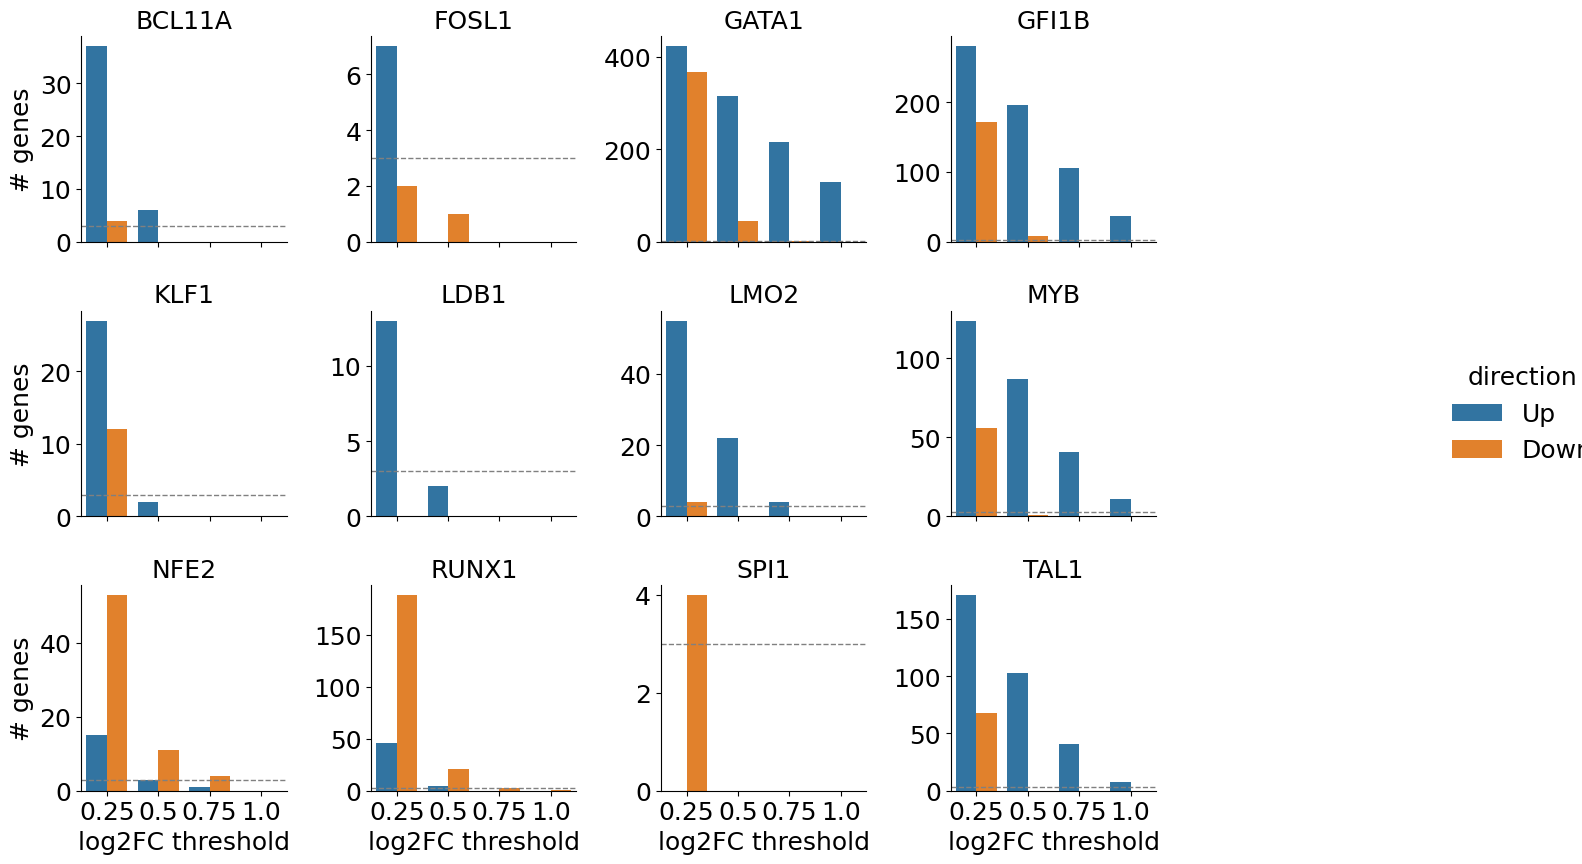

In [13]:
summary = combined_df.groupby(
    ['gene','logfc_threshold']
)[['n_up','n_down','n_eval']].median().reset_index()
summary = (
    combined_df
    .groupby(['gene','logfc_threshold'])[['n_up','n_down','n_eval']]
    .median()
    .reset_index()
)

# Melt to long format for seaborn
plot_df = summary.melt(
    id_vars=['gene','logfc_threshold'],
    value_vars=['n_up','n_down'],
    var_name='direction',
    value_name='count'
)

plot_df['direction'] = plot_df['direction'].map({
    'n_up': 'Up',
    'n_down': 'Down'
})
g = sns.catplot(
    data=plot_df,
    x='logfc_threshold',
    y='count',
    hue='direction',
    col='gene',
    kind='bar',
    col_wrap=4,          # adjust depending on layout
    height=3,
    sharey=False
)

# Add vertical dotted lines between thresholds
for ax in g.axes.flat:
    ax.axhline(3, linestyle='--', linewidth=1, color='gray')
g.legend.set_bbox_to_anchor((1.05, 0.5))
g.legend.set_loc("center left")

g.set_axis_labels("log2FC threshold", "# genes")
g.set_titles("{col_name}")
plt.savefig(os.path.join(res_dir,
            f"{date}_TF_deg_distribution.pdf"),
            dpi=300)

In [14]:
sum(combined_df['n_eval_recomputed'] == combined_df['n_total'])

105

In [15]:
# Number of true Up genes
combined_df['n_up'] = combined_df['tp'] + combined_df['fn']

# Number of true Down genes
combined_df['n_down'] = combined_df['tn'] + combined_df['fp']

# Total evaluated genes (recompute for safety)
combined_df['n_eval_recomputed'] = combined_df['tp'] + combined_df['tn'] + combined_df['fp'] + combined_df['fn']
combined_df = combined_df[((combined_df['n_down'] >= 3) & (combined_df['n_up'] >= 3))]

In [16]:
id_cols = ["gene", "model", "logfc_threshold", "method"]

# all other columns become long-format metrics
value_cols = [col for col in combined_df.columns if col not in id_cols]

df_long = combined_df.melt(
    id_vars=id_cols,
    value_vars=value_cols,
    var_name="metric",
    value_name="value"
)


In [17]:
# color palette for methods
method_colors = {
    'pad': '#56B4E9',
    'delete': '#2A5783',
    'mask': '#4C72B0'
}

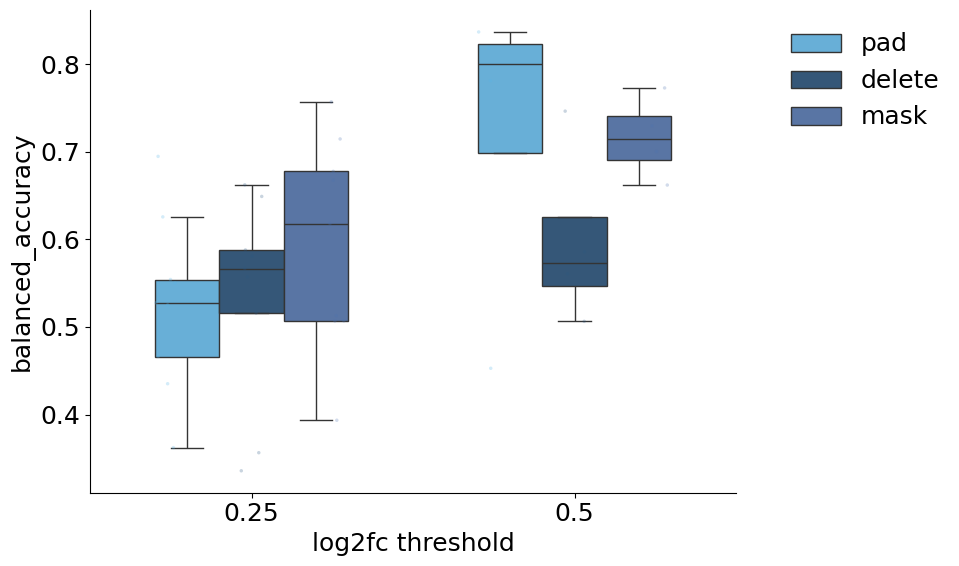

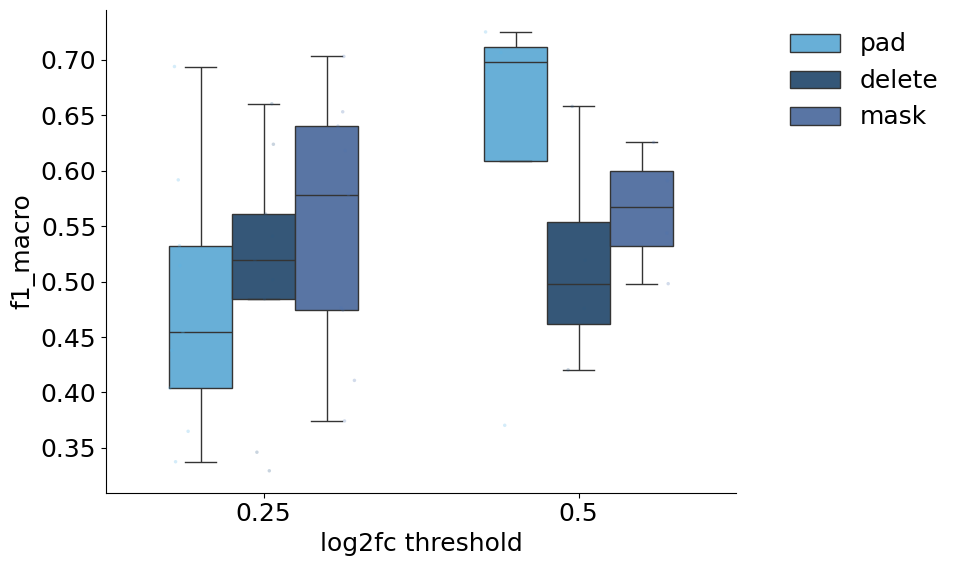

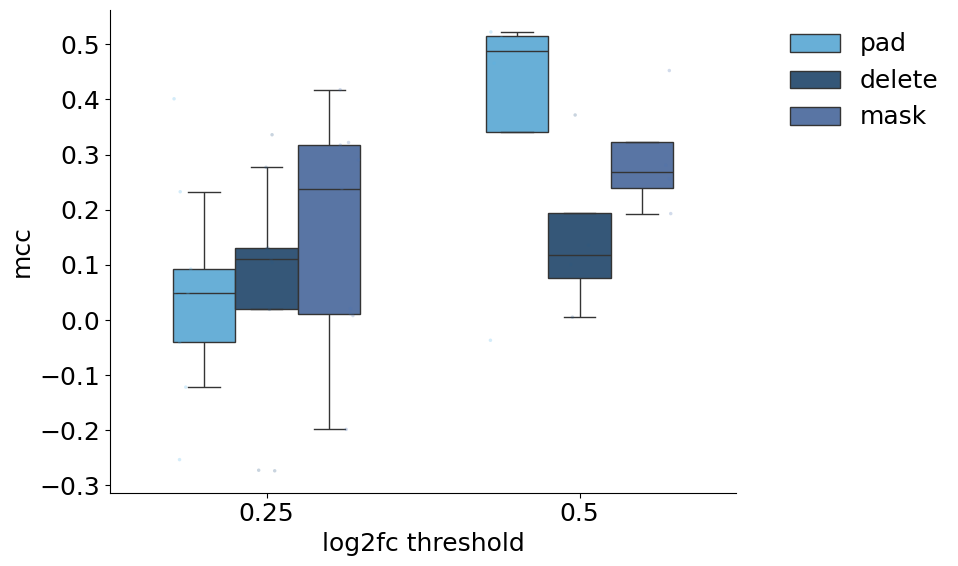

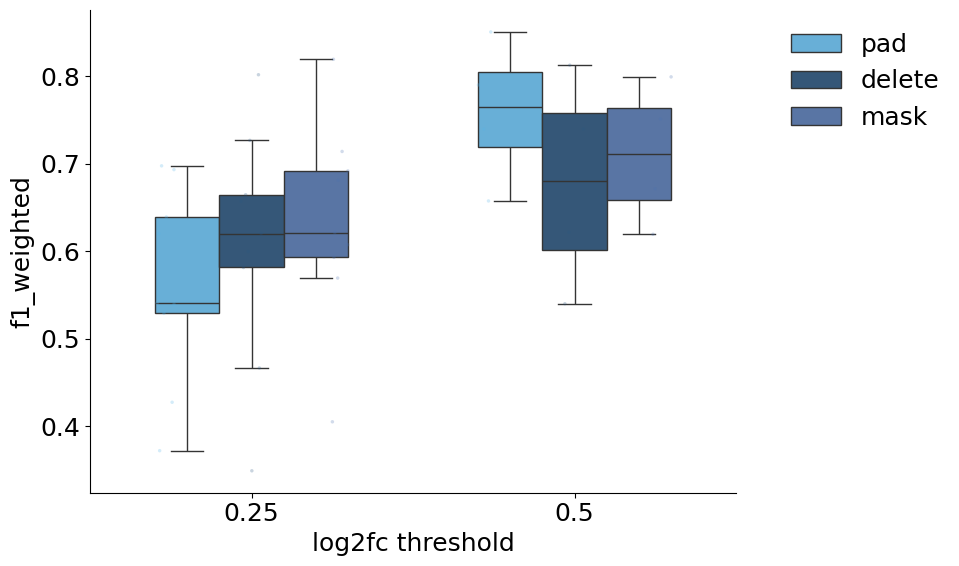

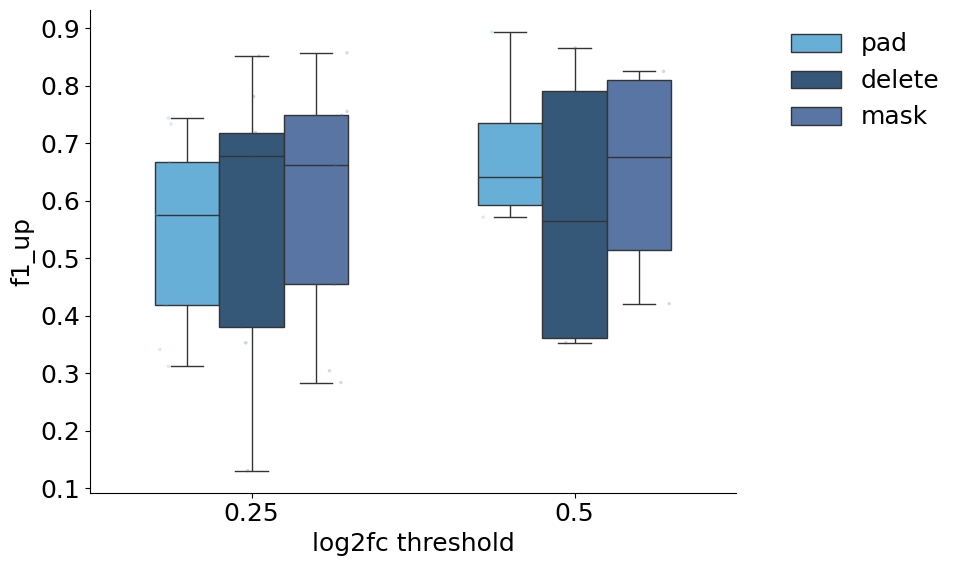

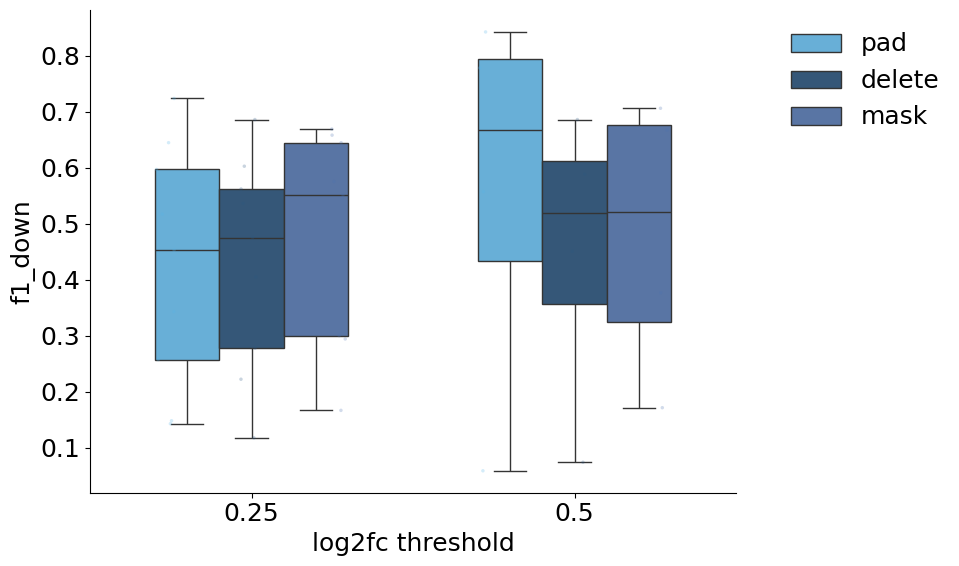

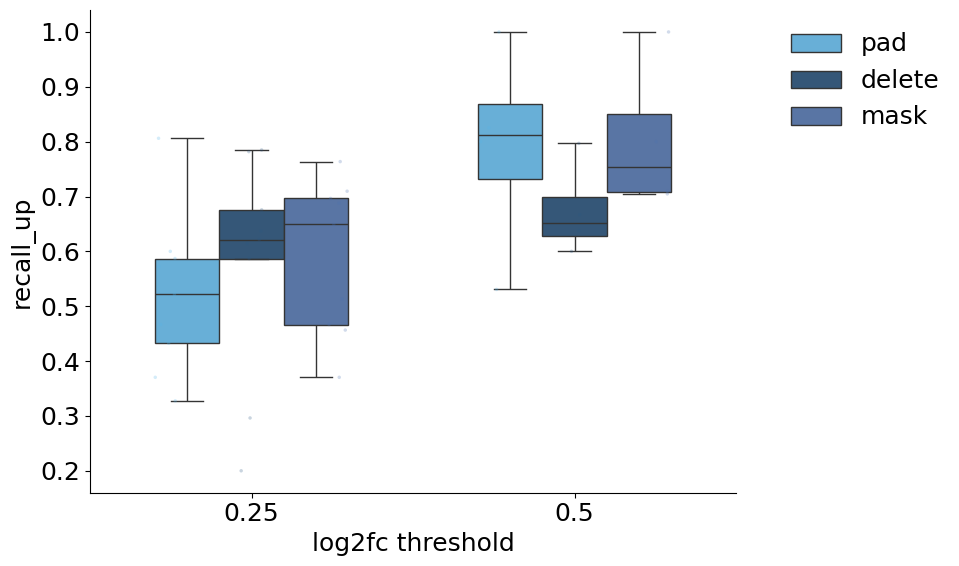

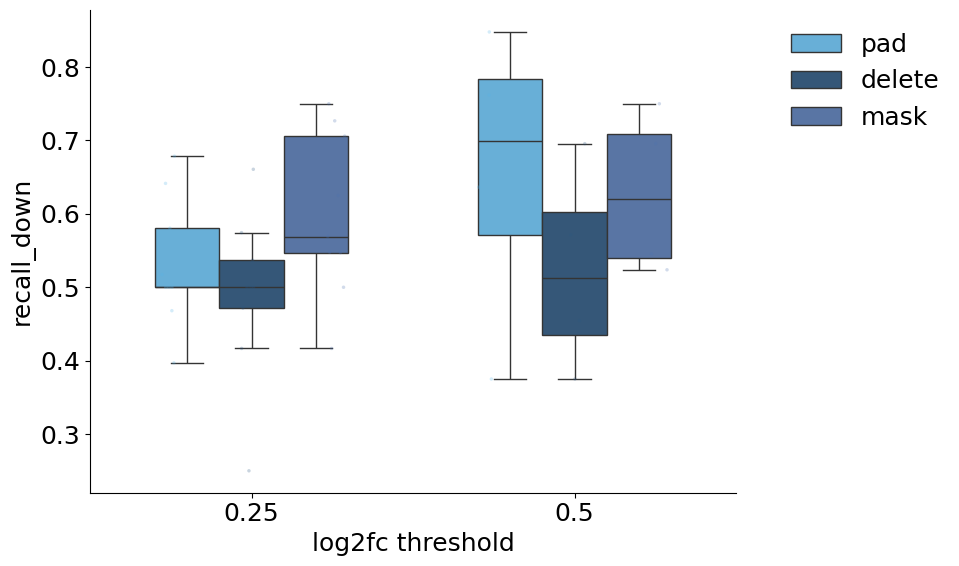

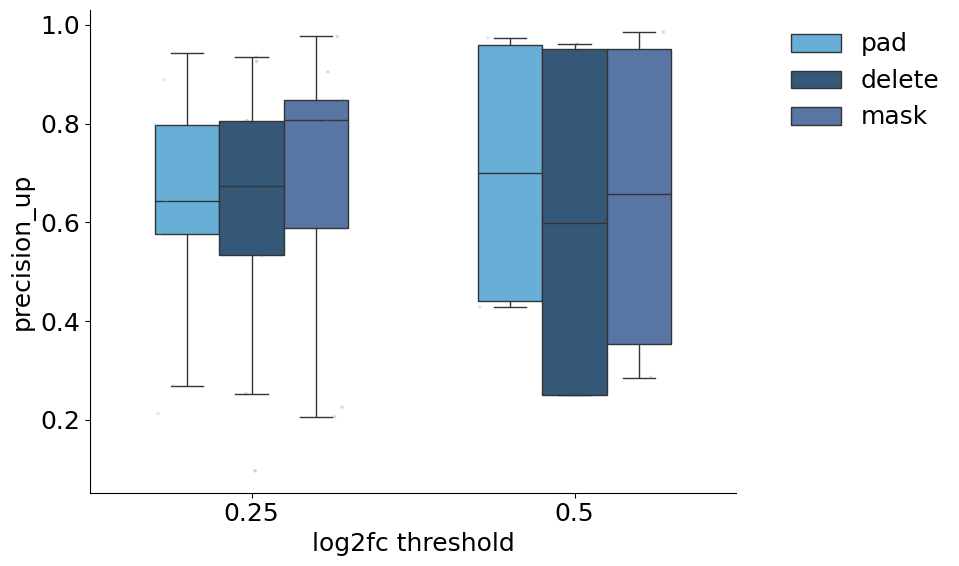

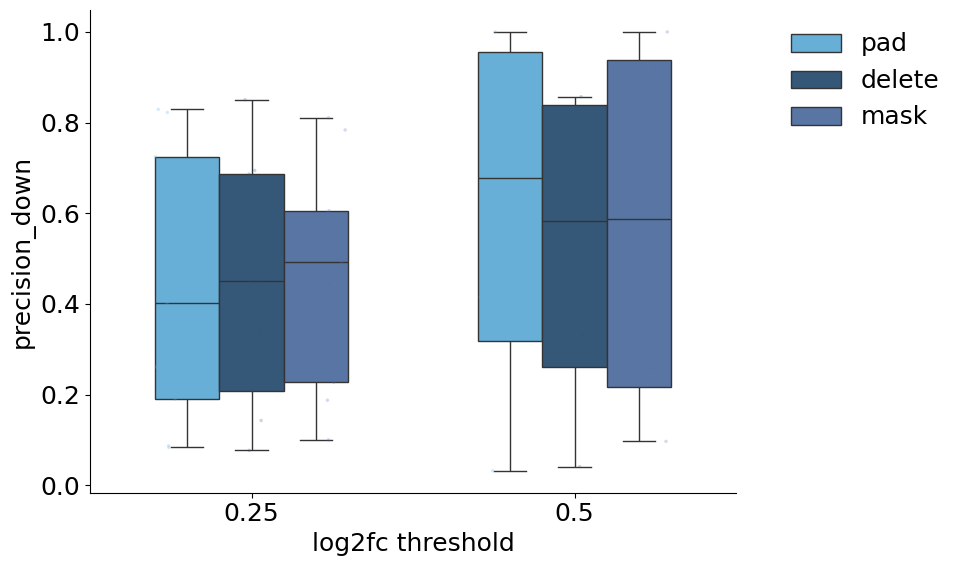

In [18]:
for metric in ['balanced_accuracy','f1_macro', 'mcc', 'f1_weighted', 'f1_up', 'f1_down', 'recall_up', 'recall_down', 'precision_up', 'precision_down']:

    df_metric = df_long[df_long['metric'] == metric].copy()
    df_metric = df_metric[df_metric['value'] != 0]
    

    plt.figure(figsize=(10, 6))

    ax = sns.boxplot(
        data=df_metric,
        x='logfc_threshold',
        y='value',
        hue='method',
        palette=method_colors,
        width=0.6,
        showfliers=False,   # raw points will show them
    )

    sns.stripplot(
        data=df_metric,
        x='logfc_threshold',
        y='value',
        hue='method',
        dodge=True,
        alpha=0.25,
        size=2.5,
        palette=method_colors,
        legend=False
    )

    ax.set_xlabel('log2fc threshold')
    ax.set_ylabel(metric)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:len(method_colors)], labels[:len(method_colors)],
              bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig(os.path.join(res_dir,
                f"{date}_perturbation_type_ablation_{metric}_supp.pdf"),
                dpi=300)

In [127]:
df_metric.groupby(['logfc_threshold','method']).size()

/tmp/ipykernel_3542030/1767450112.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_metric.groupby(['logfc_threshold','method']).size()


logfc_threshold  method
0.25             pad       9
                 delete    9
                 mask      9
0.50             pad       4
                 delete    4
                 mask      4
dtype: int64

### 2. Compare to CellOracle

In [19]:
perturbgen = pd.read_csv('/lustre/scratch126/cellgen/lotfollahi/kl11/T_perturb/res/hspc/tf_perturbation/20260225_intermediate_mask_ep14_memp_prog_metrics_direction_per_gene.csv', header=0)
celloracle_3k_n5 = pd.read_csv('/lustre/scratch126/cellgen/lotfollahi/kl11/T_perturb/res/hspc/celloracle/20260225_celloracle_3k_n5_mouse_ATAC_mk_erythro_baeoma_metrics_direction_per_gene.csv', header=0)
celloracle_3k_n3 = pd.read_csv('/lustre/scratch126/cellgen/lotfollahi/kl11/T_perturb/res/hspc/celloracle/20260225_celloracle_3k_n3_mouse_ATAC_mk_erythro_baeoma_metrics_direction_per_gene.csv', header=0)
celloracle_5k_n3 = pd.read_csv('/lustre/scratch126/cellgen/lotfollahi/kl11/T_perturb/res/hspc/celloracle/20260225_celloracle_5k_n3_mouse_ATAC_mk_erythro_baeoma_metrics_direction_per_gene.csv', header=0)
celloracle_5k_n5 = pd.read_csv('/lustre/scratch126/cellgen/lotfollahi/kl11/T_perturb/res/hspc/celloracle/20260225_celloracle_5k_n5_human_ATAC_mk_erythro_baeoma_metrics_direction_per_gene.csv', header=0)
celloracle_3k_n3_human = pd.read_csv('/lustre/scratch126/cellgen/lotfollahi/kl11/T_perturb/res/hspc/celloracle/20260226_celloracle_3k_n3_human_ATAC_mk_erythro_baeoma_metrics_direction_per_gene.csv', header=0)
celloracle_3k_n5_human = pd.read_csv('/lustre/scratch126/cellgen/lotfollahi/kl11/T_perturb/res/hspc/celloracle/20260225_celloracle_3k_n5_human_ATAC_mk_erythro_baeoma_metrics_direction_per_gene.csv', header=0)
celloracle_5k_n3_human = pd.read_csv('/lustre/scratch126/cellgen/lotfollahi/kl11/T_perturb/res/hspc/celloracle/20260226_celloracle_5k_n3_human_ATAC_mk_erythro_baeoma_metrics_direction_per_gene.csv', header=0)
celloracle_5k_n5_human = pd.read_csv('/lustre/scratch126/cellgen/lotfollahi/kl11/T_perturb/res/hspc/celloracle/20260225_celloracle_5k_n5_human_ATAC_mk_erythro_baeoma_metrics_direction_per_gene.csv', header=0)

perturbgen['method'] = 'PerturbGen'
# celloracle_3k_n5['method'] = 'CellOracle_3k_n5'
# celloracle_3k_n3['method'] = 'CellOracle_3k_n3'
celloracle_5k_n3['method'] = 'CellOracle_5k_n3'
celloracle_5k_n5['method'] = 'CellOracle_5k_n5'
# celloracle_3k_n3_human['method'] = 'CellOracle_3k_n3_human_ATAC'
# celloracle_3k_n5_human['method'] = 'CellOracle_3k_n5_human_ATAC'
celloracle_5k_n3_human['method'] = 'CellOracle_5k_n3_human_ATAC'
celloracle_5k_n5_human['method'] = 'CellOracle_5k_n5_human_ATAC'
combined_df = pd.concat([celloracle_5k_n3_human, celloracle_5k_n5_human, celloracle_5k_n3, celloracle_5k_n5, perturbgen], axis=0)
# sort method by CellOracle_5k, CellOracle_3k_n3, CellOracle_3k_n5, PerturbGen
combined_df['method'] = pd.Categorical(combined_df['method'], categories=['CellOracle_5k_n3_human_ATAC', 'CellOracle_5k_n5_human_ATAC', 'CellOracle_5k_n3', 'CellOracle_5k_n5','PerturbGen'], ordered=True)

In [20]:
# Number of true Up genes
combined_df['n_up'] = combined_df['tp'] + combined_df['fn']

# Number of true Down genes
combined_df['n_down'] = combined_df['tn'] + combined_df['fp']

# Total evaluated genes (recompute for safety)
combined_df['n_eval_recomputed'] = combined_df['tp'] + combined_df['tn'] + combined_df['fp'] + combined_df['fn']
combined_df = combined_df[((combined_df['n_down'] >= 3) & (combined_df['n_up'] >= 3))]

In [21]:
celloracle_ablation_color_dict = {
    'PerturbGen': "#4C72B0",
    # 'CellOracle_3k_n5': "#AA4499",
    # 'CellOracle_3k_n3': "#EE6677",
    'CellOracle_5k_n3': "#DDCC77",
    'CellOracle_5k_n5': "#FFB000",
    # 'CellOracle_3k_n5_human_ATAC': "#009E73",
    'CellOracle_5k_n5_human_ATAC': "#1B9E77",
    'CellOracle_3k_n3_human_ATAC': "#99D8C9",   # medium green-teal
    'CellOracle_5k_n3_human_ATAC':   "#66C2A5"  # very light mint
}

In [22]:
id_cols = ["gene", "model", "logfc_threshold", "method"]

# all other columns become long-format metrics
value_cols = [col for col in combined_df.columns if col not in id_cols]

df_long = combined_df.melt(
    id_vars=id_cols,
    value_vars=value_cols,
    var_name="metric",
    value_name="value"
)


In [23]:
df_long

,gene,model,logfc_threshold,method,metric,value
0,BCL11A,celloracle,0.25,CellOracle_5k_n3_human_ATAC,n_total,41
1,NFE2,celloracle,0.25,CellOracle_5k_n3_human_ATAC,n_total,70
2,NFE2,celloracle,0.50,CellOracle_5k_n3_human_ATAC,n_total,14
3,LMO2,celloracle,0.25,CellOracle_5k_n3_human_ATAC,n_total,62
4,MYB,celloracle,0.25,CellOracle_5k_n3_human_ATAC,n_total,182
...,...,...,...,...,...,...
1421,TAL1,perturbgen,0.25,PerturbGen,n_eval_recomputed,229
1422,GFI1B,perturbgen,0.25,PerturbGen,n_eval_recomputed,442
1423,GFI1B,perturbgen,0.50,PerturbGen,n_eval_recomputed,200
1424,GATA1,perturbgen,0.25,PerturbGen,n_eval_recomputed,743


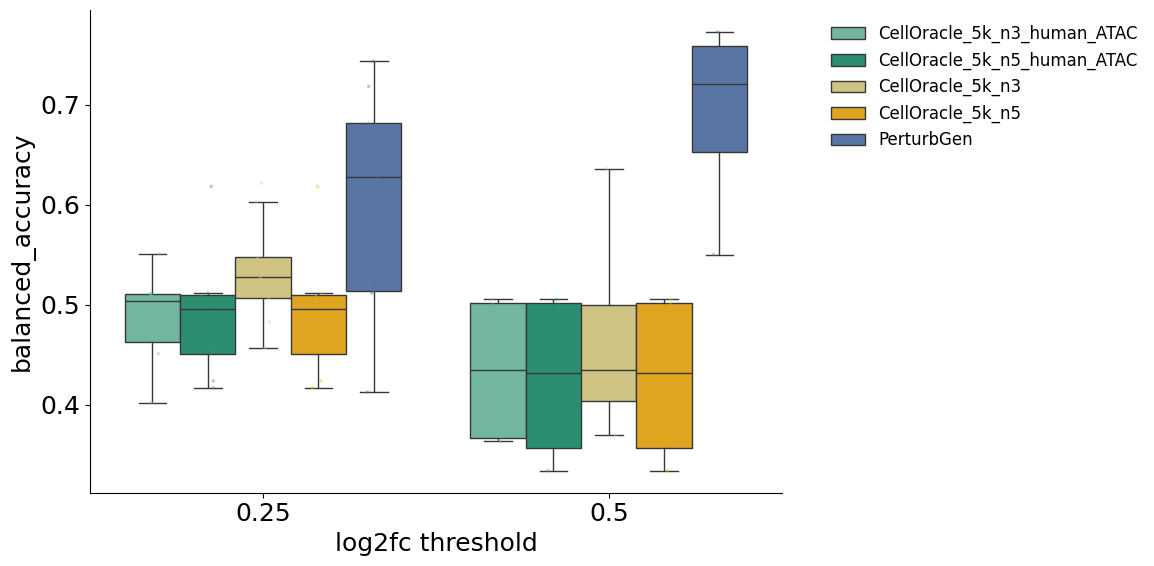

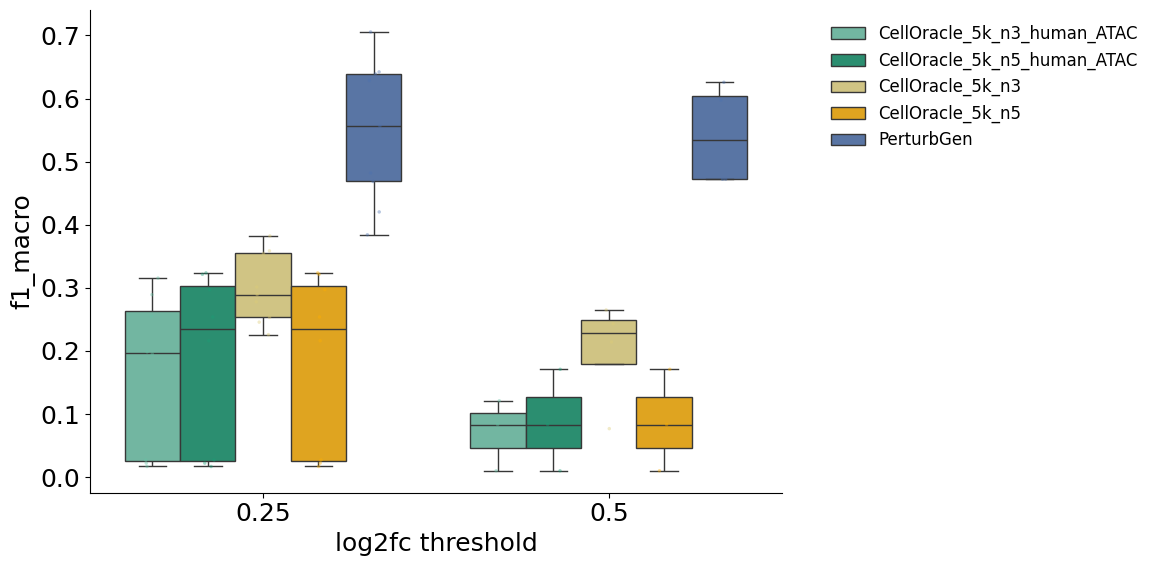

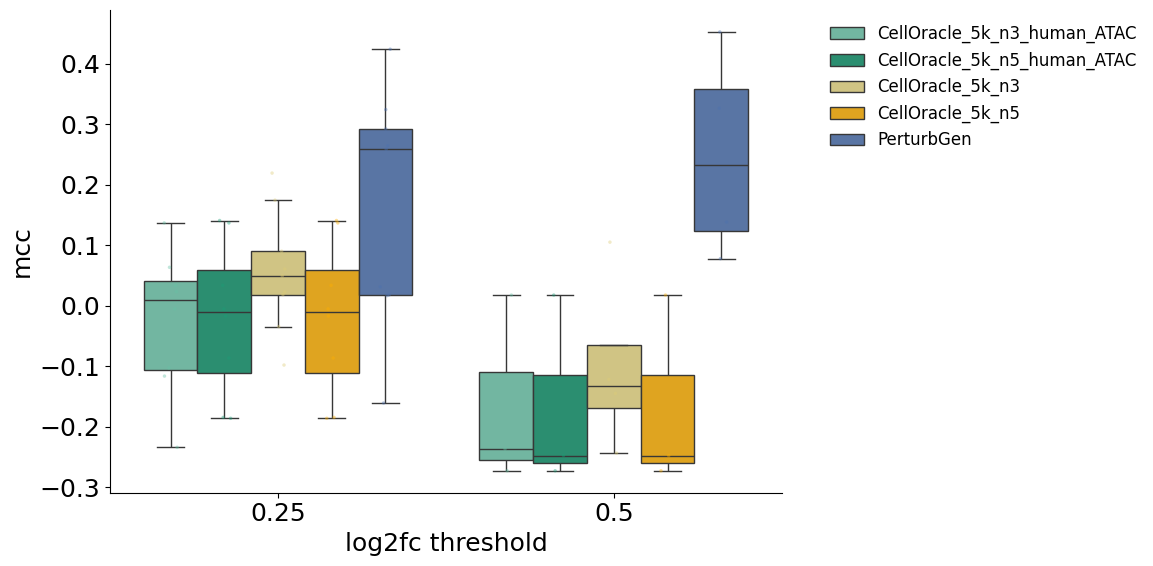

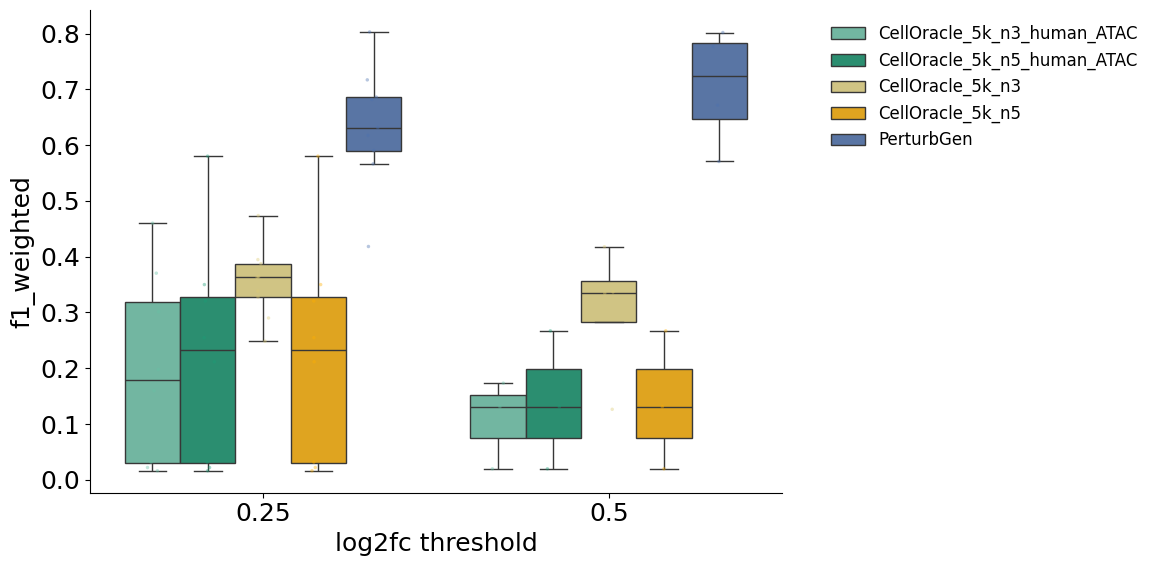

In [ ]:
x_order = sorted(df_long["logfc_threshold"].unique())
hue_order = combined_df['method'].cat.categories.tolist()
for metric in ['balanced_accuracy','f1_macro', 'mcc', 'f1_weighted']:

    df_metric = df_long[df_long['metric'] == metric].copy()
    df_metric = df_metric[df_metric['value'] != 0]

    # Make x categorical + ordered so both plots use identical positions
    df_metric["logfc_threshold"] = pd.Categorical(
        df_metric["logfc_threshold"],
        categories=x_order,
        ordered=True
    )

    plt.figure(figsize=(12, 6))

    ax = sns.boxplot(
        data=df_metric,
        x='logfc_threshold',
        y='value',
        hue='method',
        order=x_order,
        hue_order=hue_order,
        palette=celloracle_ablation_color_dict,
        # width=0.9,
        showfliers=False,
    )

    sns.stripplot(
        data=df_metric,
        x='logfc_threshold',
        y='value',
        hue='method',
        order=x_order,
        hue_order=hue_order,
        dodge=True,
        jitter=0.1,
        alpha=0.4,
        size=2.5,
        palette=celloracle_ablation_color_dict,
        legend=False,
        ax=ax
    )

    ax.set_xlabel('log2fc threshold')
    ax.set_ylabel(metric)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:len(hue_order)], labels[:len(hue_order)],
              bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

    plt.tight_layout()
    plt.savefig(os.path.join(res_dir,
                f"{date}_perturbation_type_celloracle_ablation_{metric}_supp.pdf"),
                dpi=300)

In [25]:
df_metric.groupby(['logfc_threshold','method']).size()

/tmp/ipykernel_2464099/1767450112.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_metric.groupby(['logfc_threshold','method']).size()


logfc_threshold  method                     
0.25             CellOracle_5k_n3_human_ATAC    8
                 CellOracle_5k_n5_human_ATAC    8
                 CellOracle_5k_n3               9
                 CellOracle_5k_n5               8
                 PerturbGen                     9
0.50             CellOracle_5k_n3_human_ATAC    3
                 CellOracle_5k_n5_human_ATAC    3
                 CellOracle_5k_n3               4
                 CellOracle_5k_n5               3
                 PerturbGen                     4
dtype: int64

In [26]:
# # plot comparison of methods
# for metric in combined_df['metric'].unique():
#     plt.figure(figsize=(10, 6))
#     sns.barplot(
#         data=combined_df[combined_df['metric'] == metric],
#         x='logfc_threshold', y='value', hue='method', palette=celloracle_color_dict,
#     )
#     plt.xlabel('log2fc threshold')
#     plt.ylabel(f'{metric}')
#     # plot legend outside of box
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#     # plt.savefig(os.path.join(res_dir, f"{date}_method_comparison_{metric}.pdf"), bbox_inches='tight', dpi=300)

In [27]:
celloracle_color_dict = {
    'PerturbGen': "#4C72B0",
    'CellOracle_default': "#FFB000",
    'CellOracle_human': "#009E73"
}

In [28]:
df_long.metric.value_counts()

metric
n_total                   62
n_eval                    62
coverage_pred_nonzero     62
abstain_rate_pred_zero    62
handle_zeros              62
tp                        62
fp                        62
fn                        62
tn                        62
accuracy                  62
balanced_accuracy         62
mcc                       62
precision_up              62
recall_up                 62
f1_up                     62
precision_down            62
recall_down               62
f1_down                   62
f1_macro                  62
f1_weighted               62
n_up                      62
n_down                    62
n_eval_recomputed         62
Name: count, dtype: int64

/tmp/ipykernel_2464099/1283671292.py:20: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_long_bal_acc['method'] = df_long_bal_acc['method'].replace({


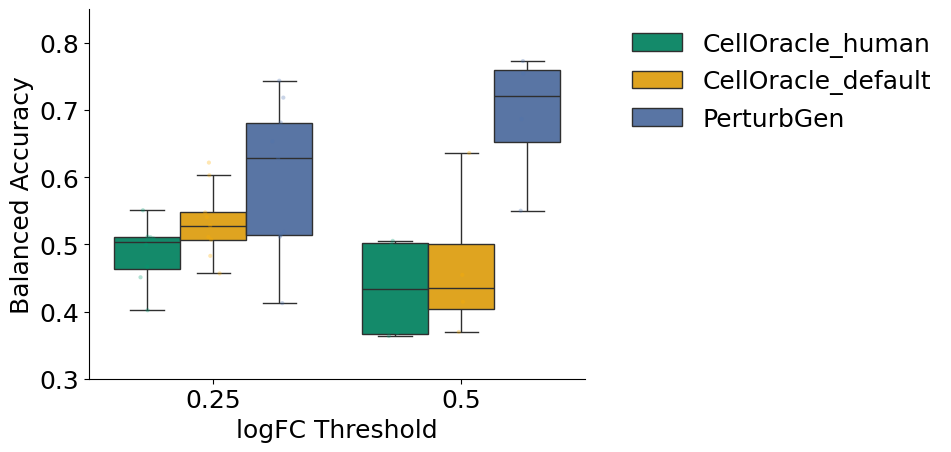

In [ ]:
# filter for logfc thresholds 0.25 and 0.5

# keep only balanced accuracy
df_long_bal_acc = df_long[
    df_long['metric'] == 'balanced_accuracy'
]
x_order = sorted(df_long_bal_acc["logfc_threshold"].unique())


# only select relevant methods
df_long_bal_acc = df_long_bal_acc[
    df_long_bal_acc['method'].isin([
        'PerturbGen',
        'CellOracle_5k_n3_human_ATAC',
        'CellOracle_5k_n3',
    ])
]

# rename methods
df_long_bal_acc['method'] = df_long_bal_acc['method'].replace({
    # 'CellOracle_5k_n5': 'CellOracle_mouse',
    'CellOracle_5k_n3_human_ATAC': 'CellOracle_human',
    'CellOracle_5k_n3': 'CellOracle_default'
})
hue_order = ['CellOracle_human', 'CellOracle_default', 'PerturbGen']

# remove unused categories (if categorical)
if hasattr(df_long_bal_acc['method'], "cat"):
    df_long_bal_acc['method'] = (
        df_long_bal_acc['method'].cat.remove_unused_categories()
    )

# plot boxplot
    ax = sns.boxplot(
        data=df_long_bal_acc,
        x='logfc_threshold',
        y='value',
        hue='method',
        palette=celloracle_color_dict,
        
        showfliers=False,   # raw points will show them
        hue_order=hue_order,
    )

    sns.stripplot(
        data=df_long_bal_acc,
        x='logfc_threshold',
        y='value',
        hue='method',
        dodge=True,
        alpha=0.3,
        jitter=0.1,
        size=3,
        palette=celloracle_color_dict,
        legend=False,
        hue_order=hue_order,
    )

plt.xlabel('logFC Threshold')
plt.ylabel('Balanced Accuracy')
# plt.ylim(0, 1)

plt.ylim(0.3, 0.85)
# legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig(
    os.path.join(res_dir, f"{date}_balanced_accuracy_logfc_025_05_boxplot.pdf"),
    bbox_inches='tight',
    dpi=300
)

plt.show()

In [30]:
df_long_bal_acc.groupby(['method','logfc_threshold', 'metric'])['value'].median()

/tmp/ipykernel_2464099/1128371125.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_long_bal_acc.groupby(['method','logfc_threshold', 'metric'])['value'].median()


method              logfc_threshold  metric           
CellOracle_human    0.25             balanced_accuracy    0.504022
                    0.50             balanced_accuracy    0.434079
CellOracle_default  0.25             balanced_accuracy    0.527509
                    0.50             balanced_accuracy    0.434512
PerturbGen          0.25             balanced_accuracy    0.628024
                    0.50             balanced_accuracy    0.720434
Name: value, dtype: object

In [31]:
df_long.metric.value_counts()

metric
n_total                   62
n_eval                    62
coverage_pred_nonzero     62
abstain_rate_pred_zero    62
handle_zeros              62
tp                        62
fp                        62
fn                        62
tn                        62
accuracy                  62
balanced_accuracy         62
mcc                       62
precision_up              62
recall_up                 62
f1_up                     62
precision_down            62
recall_down               62
f1_down                   62
f1_macro                  62
f1_weighted               62
n_up                      62
n_down                    62
n_eval_recomputed         62
Name: count, dtype: int64

/tmp/ipykernel_2464099/2917244530.py:20: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_long_f1['method'] = df_long_f1['method'].replace({


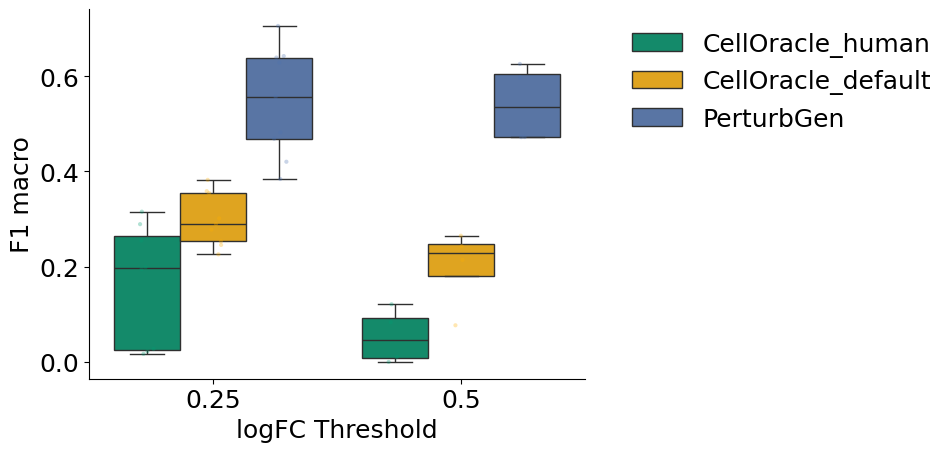

In [ ]:
# filter for logfc thresholds 0.25 and 0.5

# keep only balanced accuracy
df_long_f1 = df_long[
    df_long['metric'] == 'f1_macro'
]
x_order = sorted(df_long_f1["logfc_threshold"].unique())


# only select relevant methods
df_long_f1 = df_long_f1[
    df_long_f1['method'].isin([
        'PerturbGen',
        'CellOracle_5k_n3_human_ATAC',
        'CellOracle_5k_n3',
    ])
]

# rename methods
df_long_f1['method'] = df_long_f1['method'].replace({
    # 'CellOracle_5k_n5': 'CellOracle_mouse',
    'CellOracle_5k_n3_human_ATAC': 'CellOracle_human',
    'CellOracle_5k_n3': 'CellOracle_default'
})
hue_order = ['CellOracle_human', 'CellOracle_default', 'PerturbGen']

# remove unused categories (if categorical)
if hasattr(df_long_f1['method'], "cat"):
    df_long_f1['method'] = (
        df_long_f1['method'].cat.remove_unused_categories()
    )

# plot boxplot
    ax = sns.boxplot(
        data=df_long_f1,
        x='logfc_threshold',
        y='value',
        hue='method',
        palette=celloracle_color_dict,
        
        showfliers=False,   # raw points will show them
        hue_order=hue_order,
    )

    sns.stripplot(
        data=df_long_f1,
        x='logfc_threshold',
        y='value',
        hue='method',
        dodge=True,
        alpha=0.3,
        jitter=0.1,
        size=3,
        palette=celloracle_color_dict,
        legend=False,
        hue_order=hue_order,
    )

plt.xlabel('logFC Threshold')
plt.ylabel('F1 macro')

# legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig(
    os.path.join(res_dir, f"{date}_f1_logfc_025_05_boxplot.pdf"),
    bbox_inches='tight',
    dpi=300
)

plt.show()

In [33]:
df_long_f1.groupby(['method','logfc_threshold', 'metric'])['value'].median()

/tmp/ipykernel_2464099/2459046412.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_long_f1.groupby(['method','logfc_threshold', 'metric'])['value'].median()


method              logfc_threshold  metric  
CellOracle_human    0.25             f1_macro    0.196855
                    0.50             f1_macro    0.046743
CellOracle_default  0.25             f1_macro    0.289373
                    0.50             f1_macro    0.228671
PerturbGen          0.25             f1_macro    0.556364
                    0.50             f1_macro    0.534792
Name: value, dtype: object

/tmp/ipykernel_2464099/1332518645.py:19: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_bal['method'] = df_bal['method'].replace({


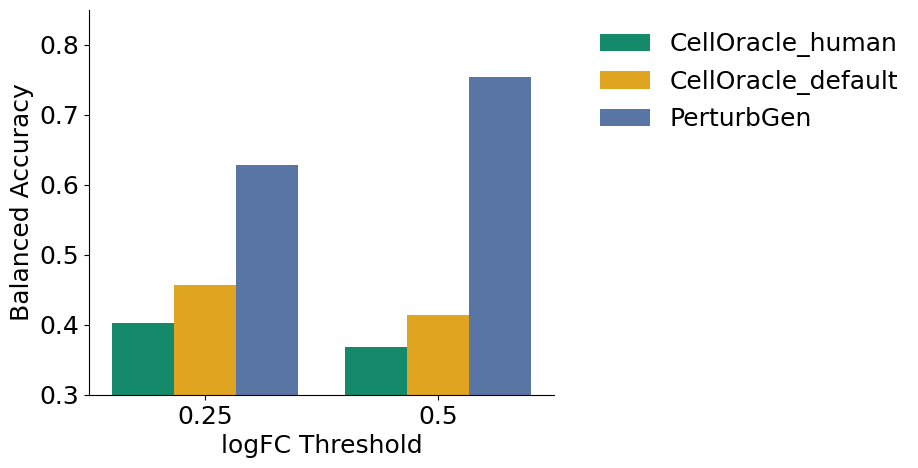

In [34]:
# filter for balanced accuracy
df_bal = df_long[
    df_long['metric'] == 'balanced_accuracy'
]

# filter for GATA1
df_bal = df_bal[df_bal['gene'] == 'GATA1']

# only select relevant methods
df_bal = df_bal[
    df_bal['method'].isin([
        'PerturbGen',
        'CellOracle_5k_n3_human_ATAC',
        'CellOracle_5k_n3',
    ])
]

# rename methods
df_bal['method'] = df_bal['method'].replace({
    'CellOracle_5k_n3_human_ATAC': 'CellOracle_human',
    'CellOracle_5k_n3': 'CellOracle_default'
})

hue_order = ['CellOracle_human', 'CellOracle_default', 'PerturbGen']

# plot barplot
plt.figure(figsize=(6, 5))

ax = sns.barplot(
    data=df_bal,
    x='logfc_threshold',
    y='value',
    hue='method',
    palette=celloracle_color_dict,
    hue_order=hue_order,
    errorbar='sd',   # or 'ci'
)

plt.xlabel('logFC Threshold')
plt.ylabel('Balanced Accuracy')
plt.ylim(0.3, 0.85)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig(
    os.path.join(res_dir, f"{date}_balanced_accuracy_GATA1_logfc_025_05_barplot_GATA1.pdf"),
    bbox_inches='tight',
    dpi=300
)

plt.show()

In [35]:
celloracle_color_dict

{'PerturbGen': '#4C72B0',
 'CellOracle_default': '#FFB000',
 'CellOracle_human': '#009E73'}

/tmp/ipykernel_2464099/2224060480.py:19: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_f1['method'] = df_f1['method'].replace({


       gene       model  logfc_threshold              method    metric  \
1126  GATA1  celloracle             0.25    CellOracle_human  f1_macro   
1127  GATA1  celloracle             0.50    CellOracle_human  f1_macro   
1151  GATA1  celloracle             0.25  CellOracle_default  f1_macro   
1152  GATA1  celloracle             0.50  CellOracle_default  f1_macro   
1176  GATA1  perturbgen             0.25          PerturbGen  f1_macro   
1177  GATA1  perturbgen             0.50          PerturbGen  f1_macro   

         value  
1126  0.198614  
1127   0.12109  
1151  0.289373  
1152  0.243056  
1176  0.628485  
1177  0.597404  
{'PerturbGen': '#4C72B0', 'CellOracle_default': '#FFB000', 'CellOracle_human': '#009E73'}
['CellOracle_human', 'CellOracle_default', 'PerturbGen']


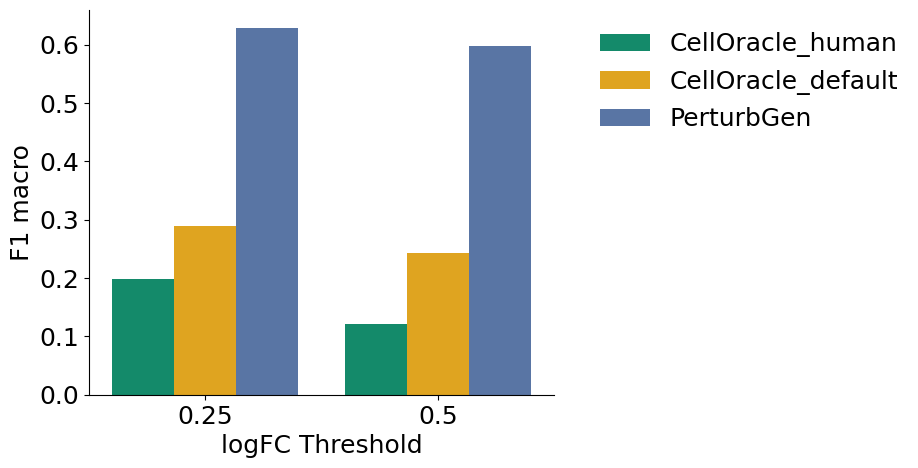

In [ ]:
# filter for balanced accuracy
df_f1 = df_long[
    df_long['metric'] == 'f1_macro'
]

# filter for GATA1
df_f1 = df_f1[df_f1['gene'] == 'GATA1']

# only select relevant methods
df_f1 = df_f1[
    df_f1['method'].isin([
        'PerturbGen',
        'CellOracle_5k_n3_human_ATAC',
        'CellOracle_5k_n3',
    ])
]

# rename methods
df_f1['method'] = df_f1['method'].replace({
    'CellOracle_5k_n3_human_ATAC': 'CellOracle_human',
    'CellOracle_5k_n3': 'CellOracle_default'
})

hue_order = ['CellOracle_human', 'CellOracle_default', 'PerturbGen']

# plot barplot
plt.figure(figsize=(6, 5))
print(df_f1)
print(celloracle_color_dict)
print(hue_order)

ax = sns.barplot(
    data=df_f1,
    x='logfc_threshold',
    y='value',
    hue='method',
    palette=celloracle_color_dict,
    hue_order=hue_order,
    # errorbar='sd',   # or 'ci'
)

plt.xlabel('logFC Threshold')
plt.ylabel('F1 macro')
# plt.ylim(0.3, 0.85)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig(
    os.path.join(res_dir, f"{date}_f1_GATA1_logfc_025_05_barplot_GATA1.pdf"),
    bbox_inches='tight',
    dpi=300
)

plt.show()

/tmp/ipykernel_2464099/1136069663.py:20: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_long_bal_acc['method'] = df_long_bal_acc['method'].replace({


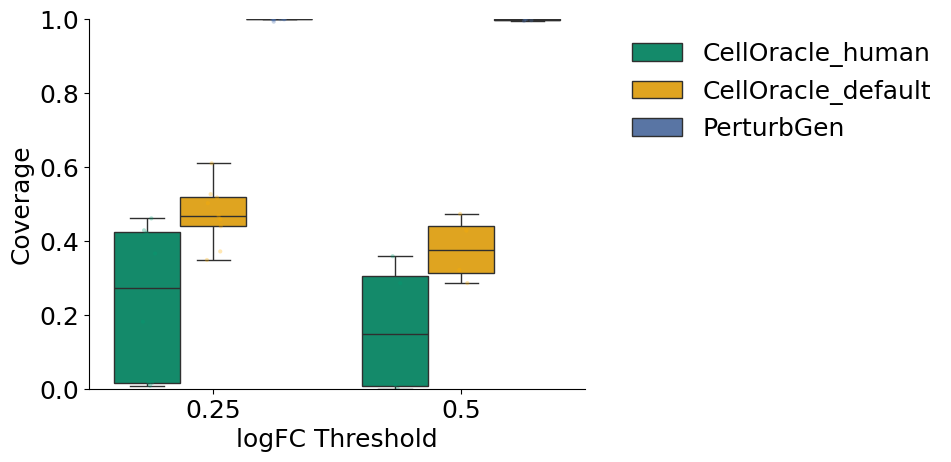

In [ ]:
# filter for logfc thresholds 0.25 and 0.5

# keep only balanced accuracy
df_long_bal_acc = df_long[
    df_long['metric'] == 'coverage_pred_nonzero'
]
x_order = sorted(df_long_bal_acc["logfc_threshold"].unique())


# only select relevant methods
df_long_bal_acc = df_long_bal_acc[
    df_long_bal_acc['method'].isin([
        'PerturbGen',
        'CellOracle_5k_n3_human_ATAC',
        'CellOracle_5k_n3',
    ])
]

# rename methods
df_long_bal_acc['method'] = df_long_bal_acc['method'].replace({
    # 'CellOracle_5k_n5': 'CellOracle_mouse',
    'CellOracle_5k_n3_human_ATAC': 'CellOracle_human',
    'CellOracle_5k_n3': 'CellOracle_default'
})
hue_order = ['CellOracle_human', 'CellOracle_default', 'PerturbGen']

# remove unused categories (if categorical)
if hasattr(df_long_bal_acc['method'], "cat"):
    df_long_bal_acc['method'] = (
        df_long_bal_acc['method'].cat.remove_unused_categories()
    )

# plot boxplot
    ax = sns.boxplot(
        data=df_long_bal_acc,
        x='logfc_threshold',
        y='value',
        hue='method',
        palette=celloracle_color_dict,
        
        showfliers=False,   # raw points will show them
        hue_order=hue_order,
    )

    sns.stripplot(
        data=df_long_bal_acc,
        x='logfc_threshold',
        y='value',
        hue='method',
        dodge=True,
        alpha=0.3,
        jitter=0.1,
        size=3,
        palette=celloracle_color_dict,
        legend=False,
        hue_order=hue_order,
    )

plt.xlabel('logFC Threshold')
plt.ylabel('Coverage')
plt.ylim(0, 1)

# legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig(
    os.path.join(res_dir, f"{date}_coverage_logfc_025_05_boxplot.pdf"),
    bbox_inches='tight',
    dpi=300
)

plt.show() 

In [38]:
df_long_bal_acc.groupby(['method','logfc_threshold', 'metric'])['value'].median()

/tmp/ipykernel_2464099/1128371125.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_long_bal_acc.groupby(['method','logfc_threshold', 'metric'])['value'].median()


method              logfc_threshold  metric               
CellOracle_human    0.25             coverage_pred_nonzero    0.273586
                    0.50             coverage_pred_nonzero    0.147832
CellOracle_default  0.25             coverage_pred_nonzero    0.467742
                    0.50             coverage_pred_nonzero    0.374645
PerturbGen          0.25             coverage_pred_nonzero         1.0
                    0.50             coverage_pred_nonzero    0.998494
Name: value, dtype: object

In [39]:
METHOD_A = "PerturbGen"
METHOD_B_LIST = ["CellOracle_5k_n3", "CellOracle_5k_n3_human_ATAC"]  # add your extra method here
FILL = 0.5  # for balanced_accuracy dropouts
pair_cols = ["gene"]

def median_iqr(arr):
    arr = np.asarray(arr)
    median = np.nanmedian(arr)
    q1 = np.nanpercentile(arr, 25)
    q3 = np.nanpercentile(arr, 75)
    return median, q1, q3

rows = []

for thr in [0.25, 0.5]:
    df = df_long[(df_long["metric"] == "balanced_accuracy") &
                 (df_long["logfc_threshold"] == thr)].copy()

    wide = df.pivot_table(index=pair_cols, columns="method", values="value", aggfunc="first")

    # ensure all needed columns exist, then fill dropouts
    needed = [METHOD_A] + METHOD_B_LIST
    for m in needed:
        if m not in wide.columns:
            wide[m] = np.nan
    wide[needed] = wide[needed].fillna(FILL)

    # per-method stats (for barplot labels/captions)
    for m in needed:
        med, q1, q3 = median_iqr(wide[m].to_numpy())
        rows.append({
            "logfc_threshold": thr,
            "type": "method_summary",
            "method": m,
            "n_pairs": wide.shape[0],
            "median": med,
            "q1": q1,
            "q3": q3
        })

    # paired differences vs PerturbGen
    x = wide[METHOD_A].to_numpy()
    for m in METHOD_B_LIST:
        y = wide[m].to_numpy()
        d = x - y
        med_d, q1_d, q3_d = median_iqr(d)
        rows.append({
            "logfc_threshold": thr,
            "type": "paired_diff_vs_PerturbGen",
            "method": m,
            "n_pairs": wide.shape[0],
            "median_diff": med_d,
            "q1_diff": q1_d,
            "q3_diff": q3_d
        })

summary = pd.DataFrame(rows)
print(summary)

   logfc_threshold                       type                       method  \
0             0.25             method_summary                   PerturbGen   
1             0.25             method_summary             CellOracle_5k_n3   
2             0.25             method_summary  CellOracle_5k_n3_human_ATAC   
3             0.25  paired_diff_vs_PerturbGen             CellOracle_5k_n3   
4             0.25  paired_diff_vs_PerturbGen  CellOracle_5k_n3_human_ATAC   
5             0.50             method_summary                   PerturbGen   
6             0.50             method_summary             CellOracle_5k_n3   
7             0.50             method_summary  CellOracle_5k_n3_human_ATAC   
8             0.50  paired_diff_vs_PerturbGen             CellOracle_5k_n3   
9             0.50  paired_diff_vs_PerturbGen  CellOracle_5k_n3_human_ATAC   

   n_pairs    median        q1        q3  median_diff   q1_diff   q3_diff  
0        9  0.628024  0.513889  0.681186          NaN       NaN  

/tmp/ipykernel_2464099/2255971859.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = df.pivot_table(index=pair_cols, columns="method", values="value", aggfunc="first")
/tmp/ipykernel_2464099/2255971859.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  wide[needed] = wide[needed].fillna(FILL)
/tmp/ipykernel_2464099/2255971859.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = df.pivot_table(index=pair_cols, columns="method", val